### Homework 1 Problem 1:
Find a dataset from the LC State Library website provided on Slack and download it into your **homework** folder. Do the following:

- Read the dataset in as a numpy array using the appropriate function and make sure it has read in properly.
- Describe in words what the dataset represents. Develop three questions you would like to answer about the data.
- Use at least three **new** statistical/numerical functions from **numpy** (go beyond average, std, and ptp) to answer the questions from (2). Be sure to explain your answer in words as well as numbers


In [1]:
import numpy as np

In [2]:
#read in dataset using numpy
data = np.genfromtxt('music_dataset.csv', delimiter=',', dtype=None, encoding=None, names=True)

In [3]:
data

array([('Track 14728', 'EchoSync', 689815326,  796199, 'Trap', 2021, 81,  8,  0.2 , 17, 0.11, 0.59, 0.6 ),
       ('Track 21319', 'The Midnight Howl', 457954557, 2426710, 'Electronic', 2018, 44, 99,  0.51, 30, 0.61, 0.25, 0.71),
       ('Track 22152', 'Retro Resonance', 217316865, 1639915, 'Reggae', 1992, 57, 12,  0.36, 11, 0.43, 0.58, 0.2 ),
       ...,
       ('Track 61735', 'Retro Resonance', 590393937, 1474438, 'K-Pop', 2014, 55, 27, -0.34,  9, 0.91, 0.83, 0.91),
       ('Track 47314', 'Bass Surge', 376858259, 1933465, 'Latin', 1996, 75, 15,  0.41, 31, 0.17, 0.03, 0.79),
       ('Track 30934', 'Shadow Beats', 262207213, 2419058, 'Blues', 2006, 15, 57,  0.37, 86, 0.51, 0.73, 0.49)],
      dtype=[('Song', '<U11'), ('Artist', '<U17'), ('Streams', '<i4'), ('Daily_Streams', '<i4'), ('Genre', '<U11'), ('Release_Year', '<i4'), ('Peak_Position', '<i4'), ('Weeks_on_Chart', '<i4'), ('Lyrics_Sentiment', '<f8'), ('TikTok_Virality', '<i4'), ('Danceability', '<f8'), ('Acousticness', '<f8'), ('En

#### Understanding the Dataset
- This dataset holds ~5000 songs. The unique ID (index) is the track number. It has the song title, artist, total streams, daily streams, Genre, Release Year, Highest position in bilboards, Number of weeks on the chart, the sentiment of lyrics, Tiktok Virality, Danceability, Acousticness, and Energy.

I've always wondered how spotify wrapped came out with those descriptors (67% of music you listened to this year was dancable). It seems like it is industry standard nowadays to associate numbers to subjective things. I wonder how they ranked danceability or energy. I see how they would get the sentiment. They would have a dictonary of words, one for positive and another for negative connotation words. Then count how much each word pops up and do a ratio.

Question 1 - What is the top 75 percentile of songs with the most TikTok Popularity?

In [4]:
percentile_75 = np.percentile(data['TikTok_Virality'], 75)
print("75th percentile of TikTok popularity:", percentile_75)

75th percentile of TikTok popularity: 76.0


What does this mean?

- 75% and below of songs in the dataset have a TikTok Popularity score of 76/100.
- That means that the remaining 25% of the songs have had a lot of popularity with TikTok
- 25% of 5000 = 1250 songs have had great success on TikTok

Question 2 - Does the genre affect the sentiment?

In [5]:
genres = np.unique(data['Genre']) # gets all unique genres
# Calculate average sentiment for each genre

for g in genres:
    avg_sentiment = np.mean(data['Lyrics_Sentiment'][data['Genre'] == g])
    print(f"Genre: {g}, Average Sentiment: {avg_sentiment:.2f}")


Genre: Blues, Average Sentiment: 0.00
Genre: Country, Average Sentiment: -0.01
Genre: Drum & Bass, Average Sentiment: 0.01
Genre: EDM, Average Sentiment: -0.01
Genre: Electronic, Average Sentiment: 0.05
Genre: Folk, Average Sentiment: -0.00
Genre: Hip-Hop, Average Sentiment: 0.00
Genre: House, Average Sentiment: -0.06
Genre: Indie, Average Sentiment: 0.01
Genre: Jazz, Average Sentiment: -0.02
Genre: K-Pop, Average Sentiment: 0.04
Genre: Latin, Average Sentiment: -0.01
Genre: Lo-Fi, Average Sentiment: -0.06
Genre: Metal, Average Sentiment: -0.01
Genre: Pop, Average Sentiment: -0.00
Genre: Punk, Average Sentiment: -0.00
Genre: R&B, Average Sentiment: 0.00
Genre: Reggae, Average Sentiment: 0.00
Genre: Rock, Average Sentiment: 0.01
Genre: Synthwave, Average Sentiment: 0.01
Genre: Techno, Average Sentiment: 0.05
Genre: Trap, Average Sentiment: 0.00


What does this mean?
- For one, the variance between the average sentiment of the genres are a lot less than I imagined. This could be due to a multitude of factors. One of which is over representation of genres. Something like Pop or Hiphop would have more representation than Reggae or Folk. 
- The most positive sentiments are Techno and Electronic and I imagine that has something to do with the fact that these mediums both have a less of an emphasis on lyrics than the others.
- Overall, there is not enough information to determine whether genre has an affect on lyric sentiment.

Question 3 - What is the corelation between danceability and Energy?

In [6]:
corelation = np.corrcoef(data['Danceability'], data['Energy'])[0, 1]
print(f"Corelation between danceability and energy: {corelation:.2f}")

Corelation between danceability and energy: 0.03


What does this mean?
- There doesn't seem to be a corelation between danceability and energy. I imagine that has something to do with how different these two categories are. For example, the way a jazz record and hiphop record might have the same danceability but the energy could be completley different.
- Again, something as subjective as danceability and energy have me questioning the validity of this dataset.

https://www.geeksforgeeks.org/numpygenfromtxt/

https://www.geeksforgeeks.org/python-numpy-np-unique-method/

https://chatgpt.com/share/67e8cf46-69ac-800f-960a-191fc4983695

### Homework 1 Problem 2:

You have been provided the `consumer_price_index.csv` dataset. Please create the following:
1. A plot of the CPI of the average price of goods (meat, fuel, grain, metal, plant extract) over time. Compile into a single plot.
2. A composite plot of four sub-plots, one for each of the groups minus one. You can choose which group to drop. For example, the first plot would show the CPI for beef, lamb, and pork.
Your plots should look professional using the tools used from class. You may need to use tools not explicitly covered in class, which you can find in the matplotlib API. They should incorporate:
    * Sizing, spacing, and scaling appropriate for the plot.
    * Non-default color schemes. Be creative.
    * Legends

Here is some code for importing the data so it doesn't error out:
headers = np.genfromtxt('consumer_price_index.csv', delimiter=',', dtype='str')[0, :]
data = np.genfromtxt('consumer_price_index.csv', delimiter=',', skip_header=1)

In [7]:
import matplotlib.pyplot as plt

In [8]:
headers = np.genfromtxt('consumer_price_index.csv', delimiter=',', dtype='str')[0, :]
data = np.genfromtxt('consumer_price_index.csv', delimiter=',', skip_header=1)
years = data[:,0]

In [9]:
headers

array(['Year', 'Data.Meat.Beef', 'Data.Meat.Lamb', 'Data.Meat.Pork',
       'Data.Meat.Average', 'Data.Fuel.Coal', 'Data.Fuel.Natural gas',
       'Data.Fuel.Petroleum', 'Data.Fuel.Average', 'Data.Grain.Corn',
       'Data.Grain.Rice', 'Data.Grain.Rye', 'Data.Grain.Wheat',
       'Data.Grain.Average', 'Data.Metal.Aluminum', 'Data.Metal.Chromium',
       'Data.Metal.Copper', 'Data.Metal.Lead', 'Data.Metal.Manganese',
       'Data.Metal.Nickel', 'Data.Metal.Steel', 'Data.Metal.Tin',
       'Data.Metal.Zinc', 'Data.Metal.Iron ore', 'Data.Metal.Gold',
       'Data.Metal.Platinum', 'Data.Metal.Silver', 'Data.Metal.Average',
       'Data.Plant extract.Cocoa', 'Data.Plant extract.Coffee',
       'Data.Plant extract.Cotton', 'Data.Plant extract.Cottonseed',
       'Data.Plant extract.Palm oil', 'Data.Plant extract.Rubber',
       'Data.Plant extract.Sugar', 'Data.Plant extract.Tea',
       'Data.Plant extract.Tobacco', 'Data.Plant extract.Average'],
      dtype='<U29')

In [10]:
print(data[:2]) #

[[1900.          100.          100.          100.          100.
   100.          100.          100.          100.          100.
   100.          100.          100.          100.          100.
   100.          100.          100.          100.          100.
   100.          100.          100.          100.          100.
   100.          100.          100.          100.          100.
   100.          100.          100.          100.          100.
   100.          100.          100.        ]
 [1901.           98.78640777   90.4146783   115.345979    101.51568836
    99.73627707   79.02912621   88.36517382   89.0435257   129.3161242
    88.79106793  108.4481522   100.4507857   106.75153251   99.69361305
   104.0785368    98.29529508   97.88714729  111.6952243   111.3592233
    88.35554484   82.25311776   91.50105175   70.62177236   98.78640777
   112.2126819    85.06607335   96.29274535   92.90888017   77.70516402
    99.36784631   98.78640777   93.59967423   86.98610503   79.93692538
    9

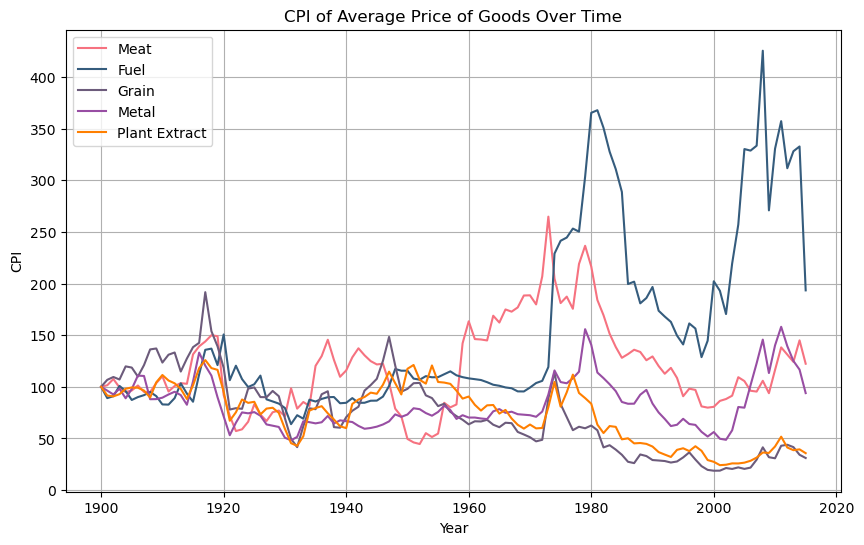

In [28]:
#get indices for each group
meat_idx = np.where(headers == 'Data.Meat.Average')[0][0]
fuel_idx = np.where(headers == 'Data.Fuel.Average')[0][0]
grain_idx = np.where(headers == 'Data.Grain.Average')[0][0]
metal_idx = np.where(headers == 'Data.Metal.Average')[0][0]
plant_idx = np.where(headers == 'Data.Plant extract.Average')[0][0]

plt.figure(figsize=(10, 6))
plt.plot(years, data[:, meat_idx], label='Meat', color='#f67280')
plt.plot(years, data[:, fuel_idx], label='Fuel', color='#355c7d')
plt.plot(years, data[:, grain_idx], label='Grain', color='#6c5b7b')
plt.plot(years, data[:, metal_idx], label='Metal', color='#984ea3')
plt.plot(years, data[:, plant_idx], label='Plant Extract', color='#ff7f00')

plt.title('CPI of Average Price of Goods Over Time')
plt.xlabel('Year')
plt.ylabel('CPI')
plt.legend()
plt.grid()
plt.show()

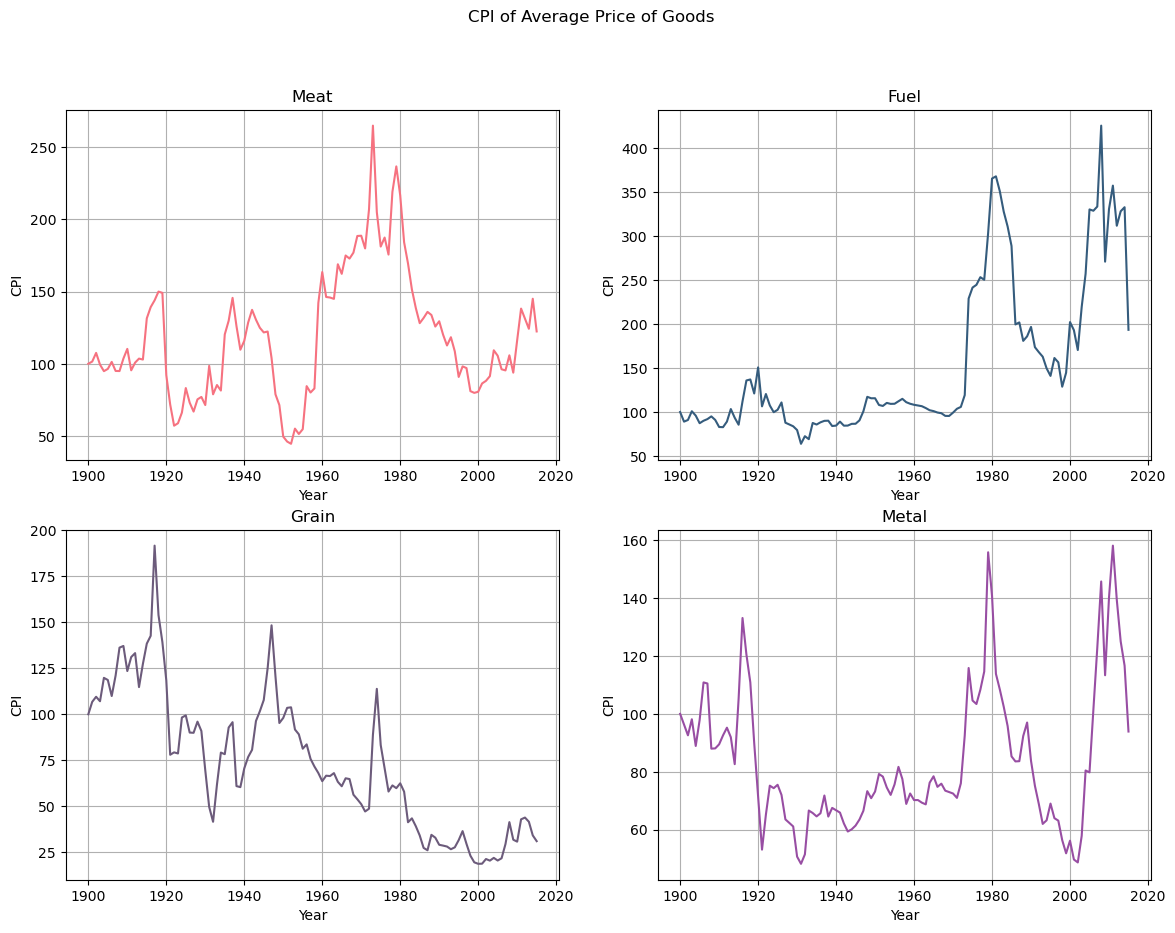

In [27]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(years, data[:, meat_idx], color='#f67280')
axs[0, 0].set_title('Meat')
axs[0, 0].set_xlabel('Year')
axs[0, 0].set_ylabel('CPI')
axs[0, 0].grid()

axs[0, 1].plot(years, data[:, fuel_idx], color='#355c7d')
axs[0, 1].set_title('Fuel')
axs[0, 1].set_xlabel('Year')
axs[0, 1].set_ylabel('CPI')
axs[0, 1].grid()

axs[1, 0].plot(years, data[:, grain_idx], color='#6c5b7b')
axs[1, 0].set_title('Grain')
axs[1, 0].set_xlabel('Year')
axs[1, 0].set_ylabel('CPI')
axs[1, 0].grid()

axs[1, 1].plot(years, data[:, metal_idx], color='#984ea3')
axs[1, 1].set_title('Metal')
axs[1, 1].set_xlabel('Year')
axs[1, 1].set_ylabel('CPI')
axs[1, 1].grid()

plt.suptitle('CPI of Average Price of Goods')
plt.show()

### Problem 3 Reflection 

On every homework assignment. This should be at least 5 sentences and demonstrate engagement with the material that goes beyond "this was hard" or "this was cool." Things you may include are:

- What was most challenging and why
- How you approached a problem
- What you learned outside of class on your own
- How material complements what you are learning in other classes
- Feel free to take it any direction you want, but it needs to meet the above criteria to get full credit


Homework 1: I originally thought that the most challenging aspect of this homework was finding a dataset that 1, interested in and 2, confident that I could follow the prompt (ie, 3 mathematical analysis that hasn't been done in class yet). Little did I know, it would be explaining the results of whatever mathematical process I subjected the dataset to. I understand that knowing what it means is the most important part of the dataset. But that doesn't make it any easier.

Homework 2: I had a lot of difficulties reading the dataset in. I felt like an idiot when I realized that you gave us a hint for it. From there, it was just simple plotting for the first part of the homework. Then the second one was a bit more complicated because I needed to plot 4 graphs in a single section. To think all it would take was a simple 2,2 in the plt.subplots thing to make everything work.

# AI Acknowledgement Statement

Please indicate if and how you used ChatGPT or other LLMs on this assignment. Use the option that best fits your use case:

* [ ] I did not use ChatGPT/LLMs.
* [X] I consulted ChatGPT/LLMs (to brainstorm, to debug, to get information, to give feedback), but I did not copy and paste or use text directly from ChatGPT/LLMs.
* [ ] I copied and pasted portions of code directly from ChatGPT/LLMs.
* [ ] I consulted other outside sources other than ChatGPT/LLMs.